# Importy i EDA

In [1]:
from scipy.io import arff
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
sns.set_style("whitegrid")

source = arff.loadarff("Dry_Bean_Dataset.arff")
df = pd.DataFrame(source[0])
df["Class"] = df["Class"].str.decode("utf-8")

num = df.drop(columns="Class")  

print("Wymiary:", df.shape)
print("Braki (NaN):", df.isna().sum().sum())
print("Duplikaty:", df.duplicated().sum())
df.head()

Wymiary: (13611, 17)
Braki (NaN): 0
Duplikaty: 68


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395.0,610.291,208.178117,173.888747,1.197191,0.549812,28715.0,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734.0,638.018,200.524796,182.734419,1.097356,0.411785,29172.0,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380.0,624.110,212.826130,175.931143,1.209713,0.562727,29690.0,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008.0,645.884,210.557999,182.516516,1.153638,0.498616,30724.0,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140.0,620.134,201.847882,190.279279,1.060798,0.333680,30417.0,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


In [2]:
desc = num.describe().T[["mean", "std", "min", "max"]]
desc["range"] = desc["max"] - desc["min"]  
desc.round(3)

,mean,std,min,max,range
Area,53048.285,29324.096,20420.000,254616.000,234196.000
Perimeter,855.283,214.290,524.736,1985.370,1460.634
MajorAxisLength,320.142,85.694,183.601,738.860,555.259
MinorAxisLength,202.271,44.970,122.513,460.198,337.686
AspectRation,1.583,0.247,1.025,2.430,1.405
Eccentricity,0.751,0.092,0.219,0.911,0.692
ConvexArea,53768.200,29774.916,20684.000,263261.000,242577.000
EquivDiameter,253.064,59.177,161.244,569.374,408.131
Extent,0.750,0.049,0.555,0.866,0.311
Solidity,0.987,0.005,0.919,0.995,0.075


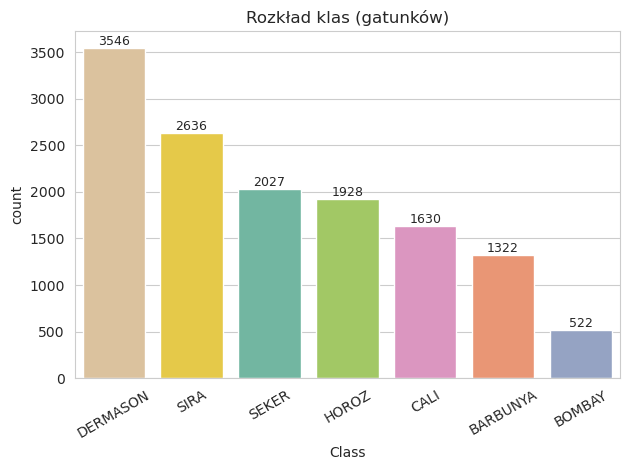

Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64


In [3]:
order = df["Class"].value_counts().index

ax = sns.countplot(data=df, x="Class", hue="Class", order=order, palette="Set2", legend=False)
ax.set_title("Rozkład klas (gatunków)")
ax.tick_params(axis="x", rotation=30)
for p in ax.patches:
    ax.annotate(int(p.get_height()),
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

print(df["Class"].value_counts())

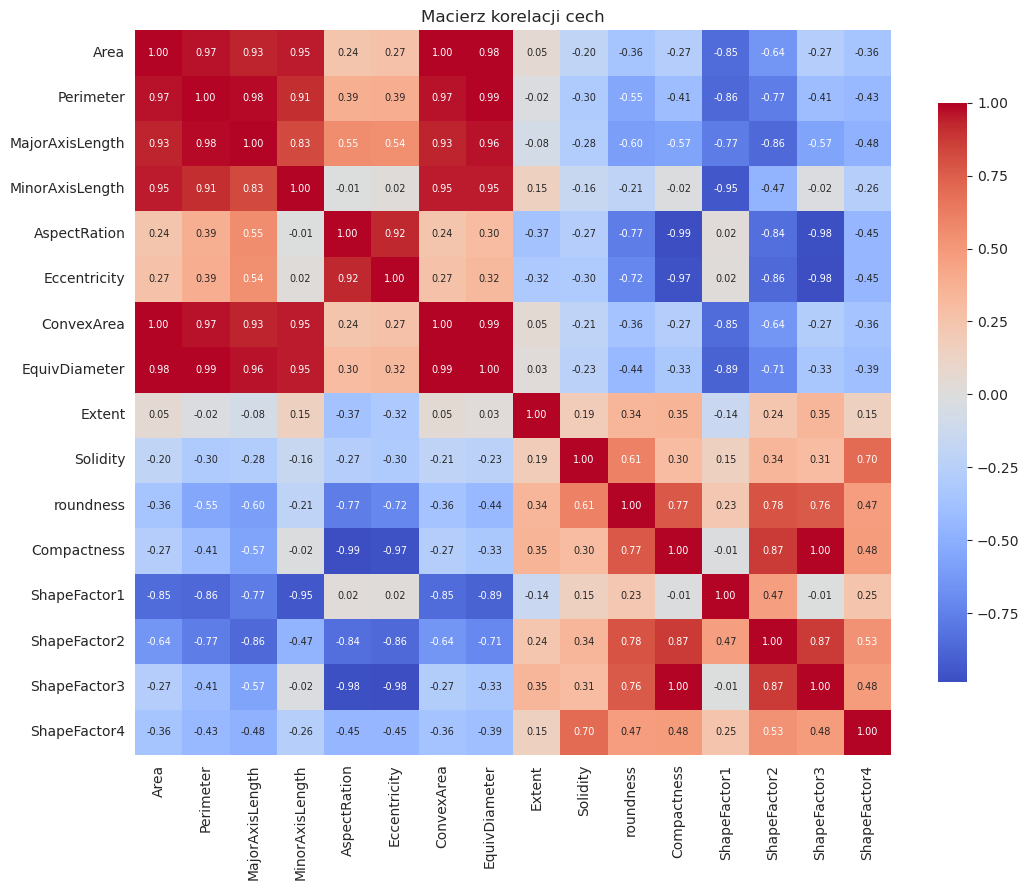

TOP 10 skorelowanych par:
  1.000  Area <-> ConvexArea
  0.999  Compactness <-> ShapeFactor3
  0.991  Perimeter <-> EquivDiameter
  0.988  AspectRation <-> Compactness
  0.985  ConvexArea <-> EquivDiameter
  0.985  Area <-> EquivDiameter
  0.981  Eccentricity <-> ShapeFactor3
  0.979  AspectRation <-> ShapeFactor3
  0.977  Perimeter <-> MajorAxisLength
  0.970  Eccentricity <-> Compactness


In [4]:
plt.figure(figsize=(11, 9))
sns.heatmap(num.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0,
            annot_kws={"size": 7}, cbar_kws={"shrink": 0.8})
plt.title("Macierz korelacji cech")
plt.tight_layout()
plt.show()

corr = num.corr().abs()
mask = np.triu(np.ones(corr.shape), 1).astype(bool)
pairs = corr.where(mask).stack().sort_values(ascending=False)

print("TOP 10 skorelowanych par:")
for (a, b), r in pairs.head(10).items():
    print(f"  {r:.3f}  {a} <-> {b}")

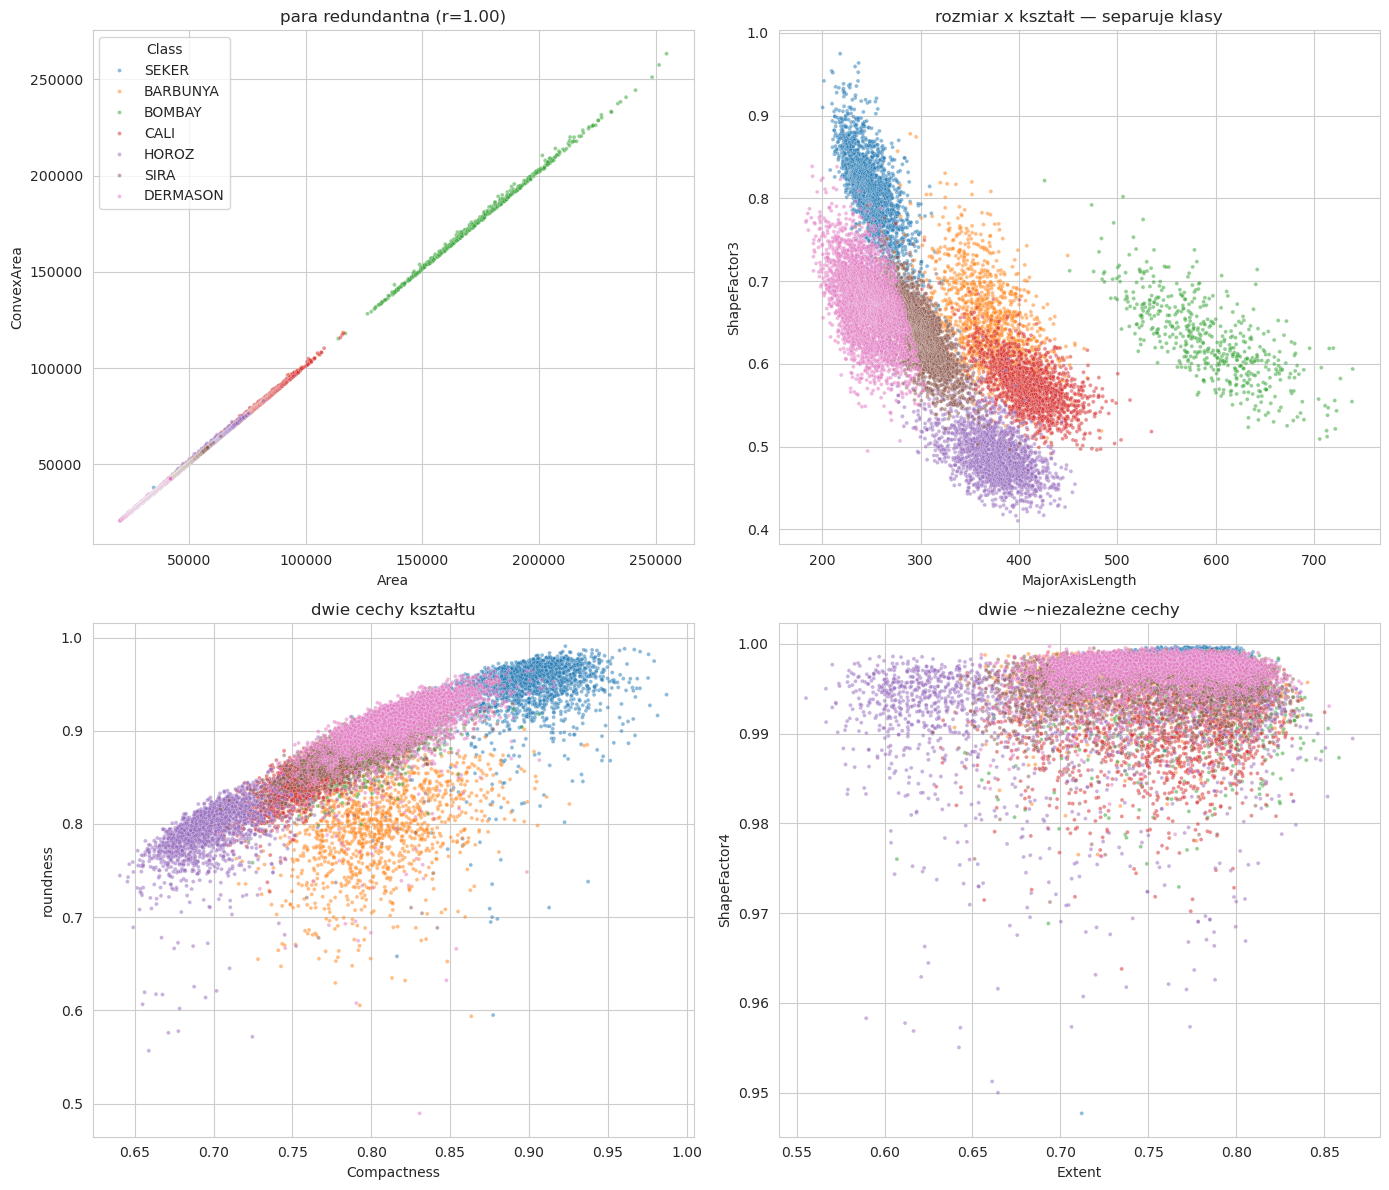

In [5]:
pairs_to_plot = [
    ("Area",            "ConvexArea",   "para redundantna (r=1.00)"),
    ("MajorAxisLength", "ShapeFactor3", "rozmiar x kształt — separuje klasy"),
    ("Compactness",     "roundness",    "dwie cechy kształtu"),
    ("Extent",          "ShapeFactor4", "dwie ~niezależne cechy"),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
for ax, (fx, fy, title) in zip(axes.ravel(), pairs_to_plot):
    sns.scatterplot(data=df, x=fx, y=fy, hue="Class", s=8, alpha=0.5,
                    palette="tab10", ax=ax, legend=(title == pairs_to_plot[0][2]))
    ax.set_title(title)
plt.tight_layout()
plt.show()

### Wnioski z analizy i decyzje

Zbiór: 13611 obserwacji, 16 cech, brak braków, 68 duplikatów (usuwamy, ~0.5%).

Klasy niezbalansowane (~6.8:1, DERMASON do BOMBAY). Nie robimy resamplingu, ale
przy ocenie patrzymy na purity i silhouette łącznie, bo purity jest czuła na imbalans.

Cechy mają skrajnie różne skale (od 0.003 do 234000), a k-średnich liczy odległość
euklidesową, więc standaryzujemy dane (StandardScaler). Wybieramy z-score zamiast
MinMax z powodu wartości odstających.

Silna współliniowość (dwa bloki: rozmiar i kształt, r > 0.95) wynika z liczenia cech
z tego samego obrysu. To redundancja, nie wyciek, więc zostawiamy wszystkie 16 cech.

## Preprocessing

In [6]:
df = df.drop_duplicates().reset_index(drop=True)
num = df.drop(columns="Class")

X = StandardScaler().fit_transform(num)

print("Po deduplikacji:", X.shape)

Po deduplikacji: (13543, 16)


## K - means

In [7]:
km = KMeans(n_clusters=7, random_state=42, n_init=10).fit(X)

print("Inercja:", round(km.inertia_, 2))
print("Rozmiary klastrów:", np.bincount(km.labels_))

Inercja: 48671.46
Rozmiary klastrów: [3158  539 1702  520 2479 2033 3112]


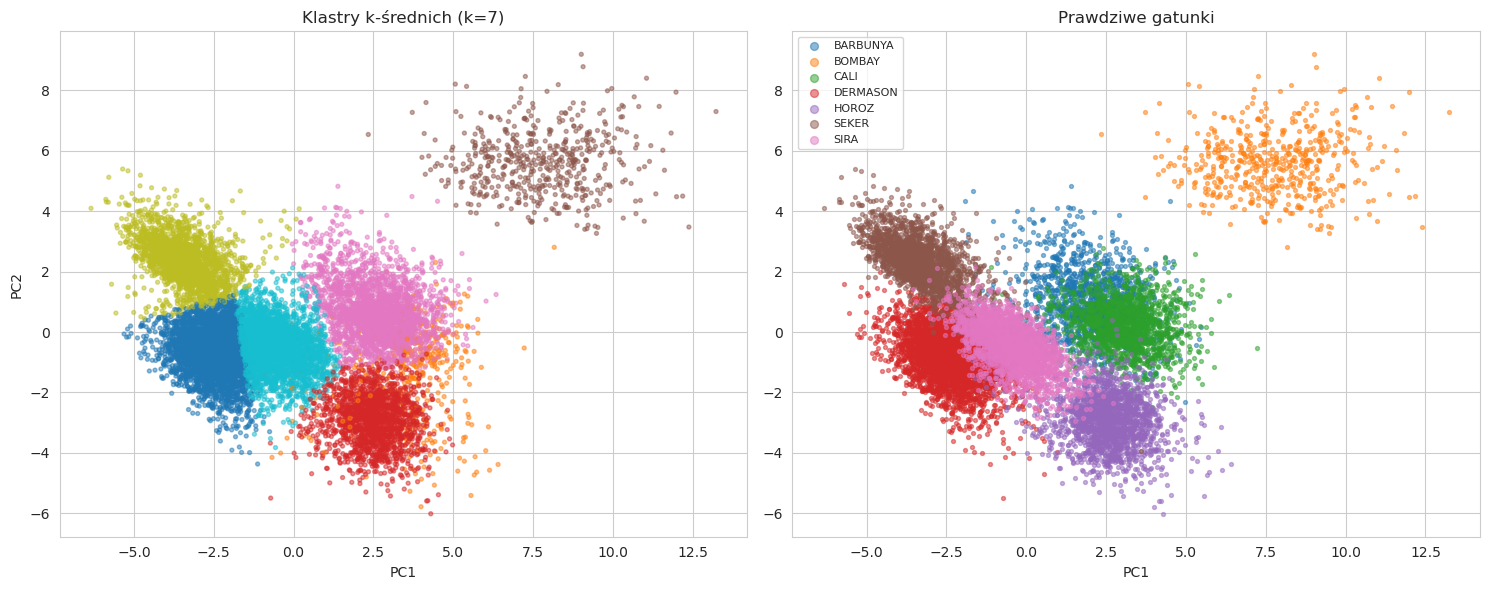

In [8]:
pca = PCA(n_components=2).fit(X)
X_2d = pca.transform(X)

def plot_clusters(X_2d, labels, true_labels, title="", method="k-średnich"):
    fig, ax = plt.subplots(1, 2, figsize=(15, 6))
       
    ax[0].scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap="tab10", s=8, alpha=0.5)
    ax[0].set_title(f"Klastry {method} {title}")
    ax[0].set_xlabel("PC1")
    ax[0].set_ylabel("PC2")

    for c in sorted(np.unique(true_labels)):
        m = true_labels == c
        ax[1].scatter(X_2d[m, 0], X_2d[m, 1], s=8, alpha=0.5, label=c)
    ax[1].set_title("Prawdziwe gatunki")
    ax[1].set_xlabel("PC1")
    ax[1].legend(markerscale=2, fontsize=8)

    plt.tight_layout()
    plt.show()

plot_clusters(X_2d, km.labels_, df["Class"].values, title="(k=7)")

In [ ]:
def purity_score(labels_true, labels_pred):
    cont = metrics.cluster.contingency_matrix(labels_true, labels_pred)
    return np.sum(np.max(cont, axis=0)) / np.sum(cont)

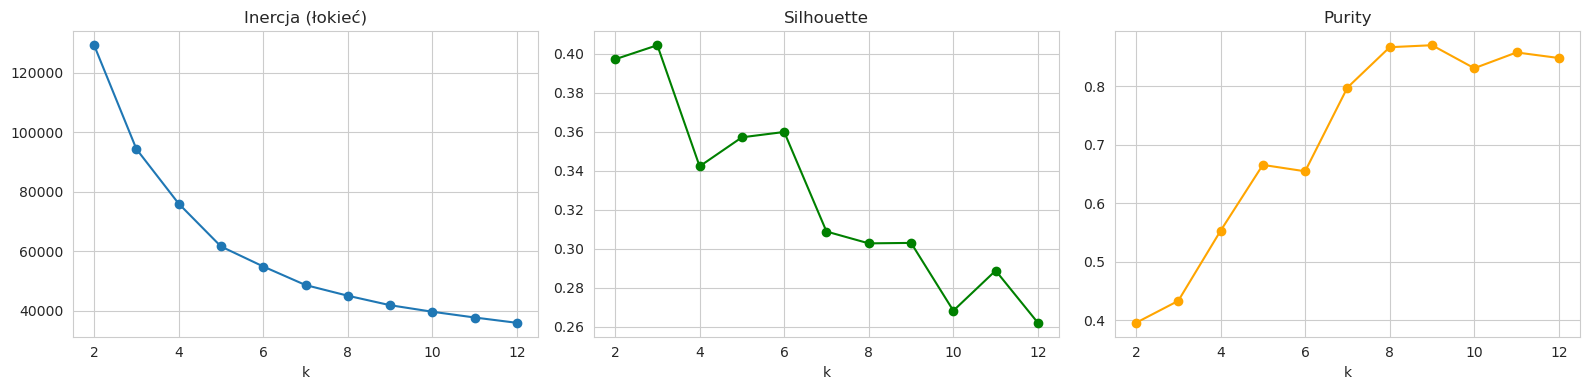

In [10]:
y_true = df["Class"].values
k_range = range(2, 13)  

inertias, silhouettes, purities = [], [], []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
    inertias.append(km.inertia_)
    silhouettes.append(metrics.silhouette_score(X, km.labels_))
    purities.append(purity_score(y_true, km.labels_))

fig, ax = plt.subplots(1, 3, figsize=(16, 4))

ax[0].plot(k_range, inertias, "o-")
ax[0].set_title("Inercja (łokieć)")
ax[0].set_xlabel("k")

ax[1].plot(k_range, silhouettes, "o-", color="green")
ax[1].set_title("Silhouette")
ax[1].set_xlabel("k")

ax[2].plot(k_range, purities, "o-", color="orange")
ax[2].set_title("Purity")
ax[2].set_xlabel("k")

plt.tight_layout()
plt.show()

Inercja maleje monotonicznie z k, z łagodnym kolanem przy k=3-4. Silhouette osiąga
maksimum przy k=3 (okolo 0.40), a purity rośnie az do k=7-8 (okolo 0.86), po czym
wchodzi w plateau.

k=3:  silhouette=0.404  purity=0.434


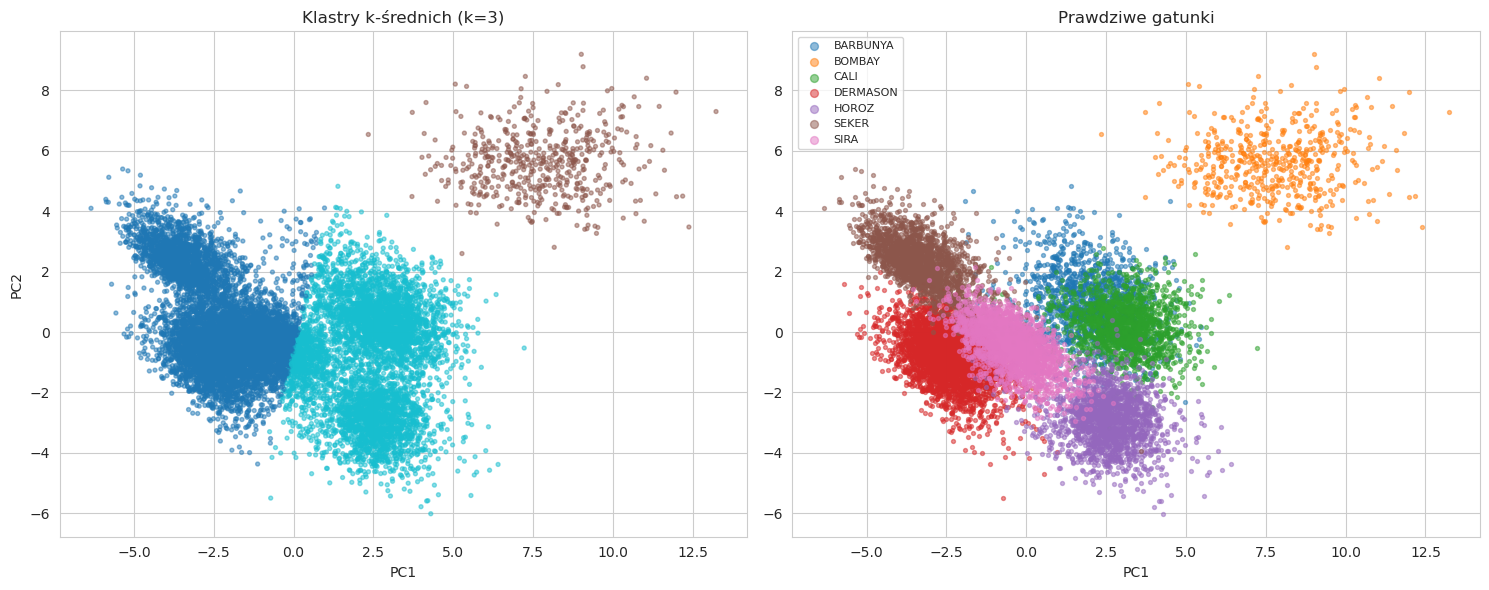

k=7:  silhouette=0.309  purity=0.798


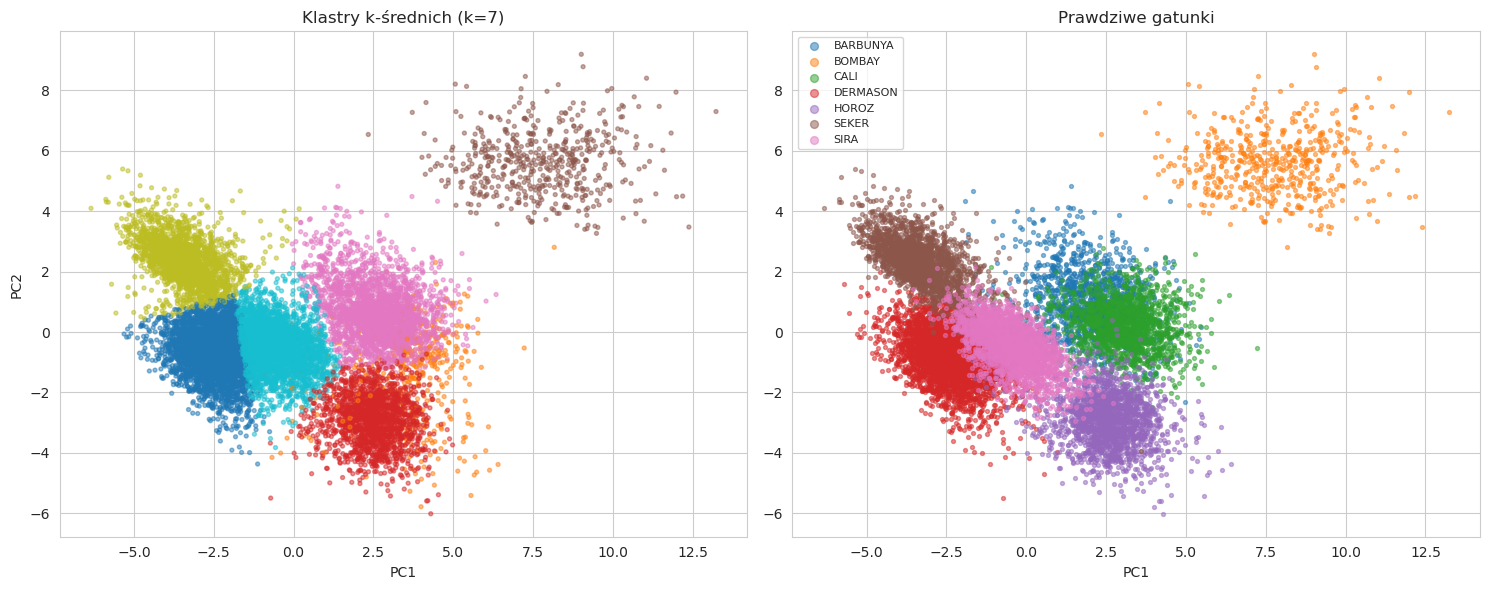

In [15]:
for k in [3, 7]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
    sil = metrics.silhouette_score(X, km.labels_)
    pur = purity_score(df["Class"].values, km.labels_)
    print(f"k={k}:  silhouette={sil:.3f}  purity={pur:.3f}")
    plot_clusters(X_2d, km.labels_, df["Class"].values, title=f"(k={k})")

Te metryki wskazują różne wartości k, ponieważ mierzą co innego. Silhouette ocenia
czystą geometrię (zwartość i separację klastrów) i wskazuje k=3, czyli liczbę naturalnych,
dobrze odseparowanych skupisk w danych. Purity mierzy zgodność z prawdziwymi gatunkami
i wskazuje k=7, czyli liczbę gatunków botanicznych.

Optymalne k zależy więc od celu. Dla odkrycia naturalnej struktury danych najlepsze jest
k=3, a dla odtworzenia znanych gatunków k=7. Jest to klasyczne napięcie między miarą
wewnętrzną a zewnętrzną w klasteryzacji.

## Klasteryzacja aglomeracyjna

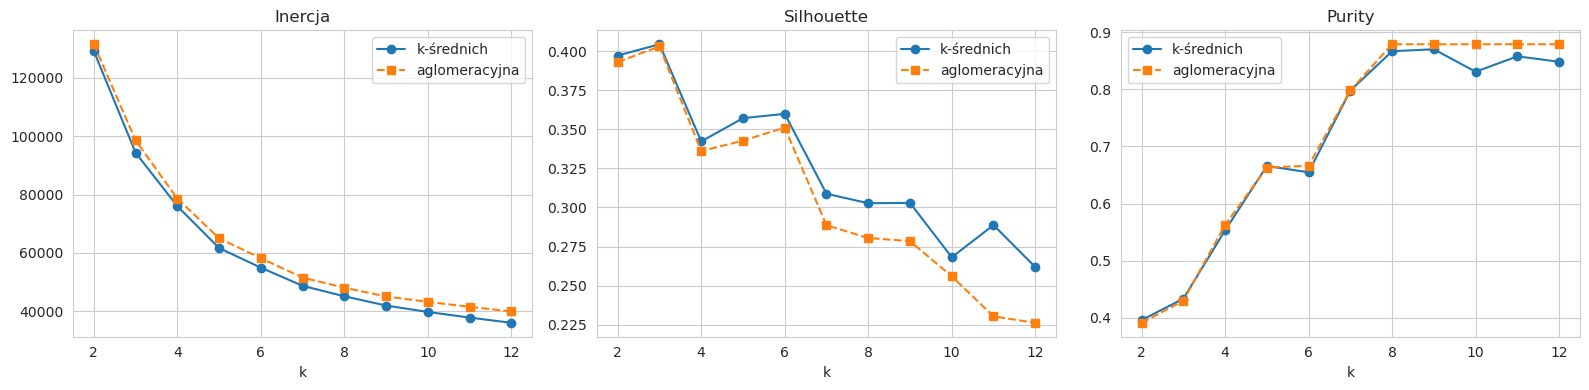

In [12]:
from sklearn.cluster import AgglomerativeClustering

inertias_a, silhouettes_a, purities_a = [], [], []

for k in k_range:
    agg = AgglomerativeClustering(n_clusters=k, linkage="ward").fit(X)
    inertia = sum(((X[agg.labels_ == c] - X[agg.labels_ == c].mean(axis=0)) ** 2).sum()
                  for c in np.unique(agg.labels_))
    inertias_a.append(inertia)
    silhouettes_a.append(metrics.silhouette_score(X, agg.labels_))
    purities_a.append(purity_score(df["Class"].values, agg.labels_))

fig, ax = plt.subplots(1, 3, figsize=(16, 4))

ax[0].plot(k_range, inertias, "o-", label="k-średnich")
ax[0].plot(k_range, inertias_a, "s--", label="aglomeracyjna")
ax[0].set_title("Inercja"); ax[0].set_xlabel("k"); ax[0].legend()

ax[1].plot(k_range, silhouettes, "o-", label="k-średnich")
ax[1].plot(k_range, silhouettes_a, "s--", label="aglomeracyjna")
ax[1].set_title("Silhouette"); ax[1].set_xlabel("k"); ax[1].legend()

ax[2].plot(k_range, purities, "o-", label="k-średnich")
ax[2].plot(k_range, purities_a, "s--", label="aglomeracyjna")
ax[2].set_title("Purity"); ax[2].set_xlabel("k"); ax[2].legend()

plt.tight_layout()
plt.show()

### Porównanie z k-średnich

Obie metody dają niemal identyczne krzywe metryk. To samo maksimum silhouette przy k=3
i to samo plateau purity przy k=7-8, czyli aglomeracyjna znajduje tę samą strukturę co
k-średnich. Wynika to z tego, że dane mają wyraźne, wypukłe skupiska, więc dwie różne
metody docierają do tego samego podziału.

Drobne różnice: inercja aglomeracyjnej leży minimalnie wyżej, ponieważ k-średnich wprost
minimalizuje inercję, a aglomeracyjna optymalizuje kryterium ward. Powyżej k=6 silhouette
aglomeracyjnej spada szybciej. Widać też, że przy k=7 aglomeracyjna nie wydziela już
gatunku BOMBAY w osobny klaster, w przeciwieństwie do k-średnich, ponieważ ward dąży do
wyrównywania rozmiarów klastrów i rozbija dużą chmurę kosztem małej, odseparowanej grupy.

Główny wniosek pozostaje taki, że jakościowo metody są równoważne, a istotna różnica
praktyczna leży w czasie działania.

k=3:  silhouette=0.403  purity=0.430


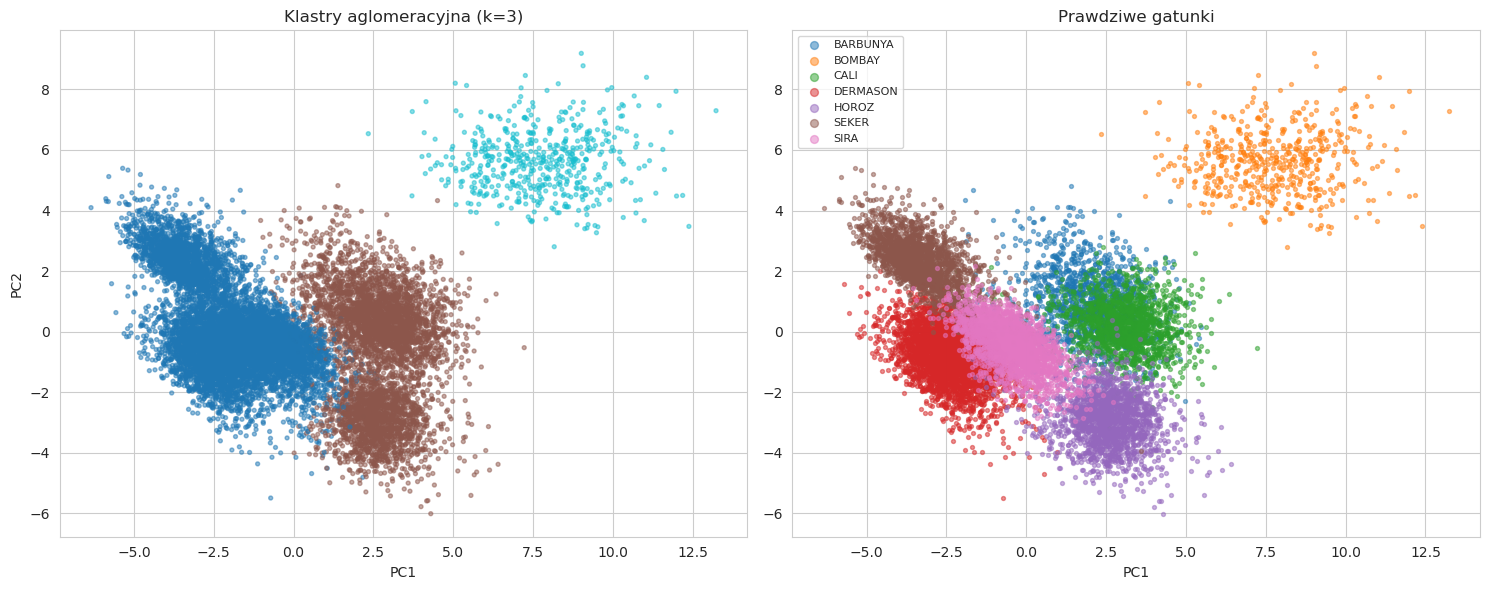

k=7:  silhouette=0.289  purity=0.798


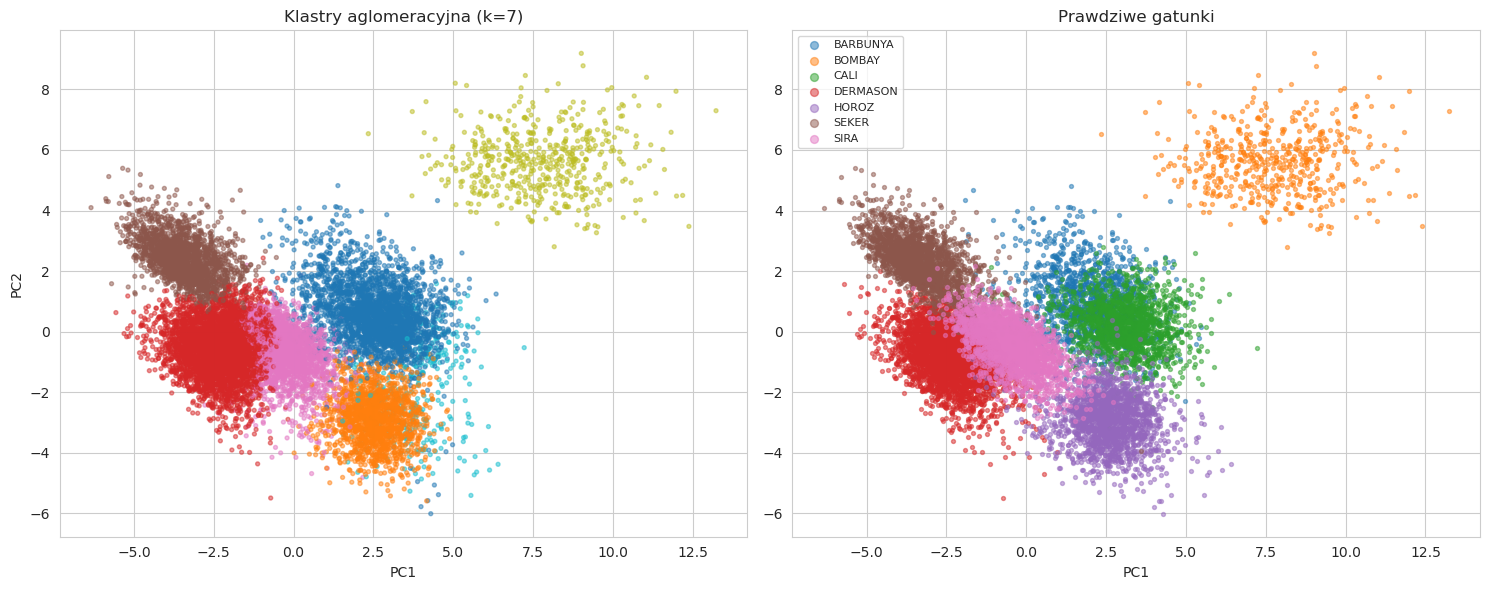

In [16]:
for k in [3, 7]:
    agg = AgglomerativeClustering(n_clusters=k, linkage="ward").fit(X)
    sil = metrics.silhouette_score(X, agg.labels_)
    pur = purity_score(df["Class"].values, agg.labels_)
    print(f"k={k}:  silhouette={sil:.3f}  purity={pur:.3f}")
    plot_clusters(X_2d, agg.labels_, df["Class"].values, title=f"(k={k})", method="aglomeracyjna")

In [14]:
import timeit

def measure(estimator_factory, X, repeats=5):
    times = timeit.repeat(lambda: estimator_factory().fit(X), repeat=repeats, number=1)
    return np.median(times)

k = 7
t_kmeans = measure(lambda: KMeans(n_clusters=k, random_state=42, n_init=10), X)
t_agg    = measure(lambda: AgglomerativeClustering(n_clusters=k, linkage="ward"), X)

print(f"k-średnich:    {t_kmeans:.3f} s")
print(f"aglomeracyjna: {t_agg:.3f} s")

k-średnich:    1.537 s
aglomeracyjna: 13.355 s


k-średnich wykonuje się w okolo 1.5 s, a aglomeracyjna w okolo 6.2 s, czyli jest okolo
4 razy wolniejsza. Wynika to z złożoności obliczeniowej. Aglomeracyjna z kryterium ward
działa w czasie kwadratowym wobec liczby punktów, ponieważ buduje hierarchię w oparciu
o odległości między parami, natomiast k-średnich jest liniowy wobec liczby punktów.
Należy zaznaczyć, że k-średnich uruchamiany jest dziesięciokrotnie (n_init=10), więc
realna przewaga pojedynczego przebiegu jest jeszcze większa.

Kluczowy wniosek jest taki, że ta różnica rośnie wraz z rozmiarem zbioru. Dla 13 tysięcy
punktów wynosi okolo czterech, ale przy dwukrotnie większym zbiorze koszt aglomeracyjnej
rośnie czterokrotnie, a k-średnich tylko dwukrotnie.Dla dużych zbiorów k-średnich jest
więc zdecydowanie korzystniejszy. Aglomeracyjna pozostaje wartościowa, gdy zależy nam na
strukturze hierarchicznej lub gdy zbiór jest na tyle mały, że czas nie stanowi problemu.